# Phase 7 Optimized CUDA Sobel (Google Colab)

Use this notebook in Google Colab with GPU runtime enabled. It creates CPU, naive CUDA, and optimized CUDA Sobel implementations, validates their outputs, runs 100 benchmark iterations for each image size, summarizes observations in data frames, and plots comparison charts.

In [1]:
!nvidia-smi

Sun Apr 12 10:22:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from pathlib import Path

Path('include').mkdir(exist_ok=True)
Path('src/common').mkdir(parents=True, exist_ok=True)
Path('src/cpu').mkdir(parents=True, exist_ok=True)
Path('src/cuda').mkdir(parents=True, exist_ok=True)
Path('src/tools').mkdir(parents=True, exist_ok=True)
Path('samples/images').mkdir(parents=True, exist_ok=True)

In [3]:
%%writefile include/image_io.hpp
#pragma once
#include <cstddef>
#include <cstdint>
#include <string>
#include <vector>

struct GrayImage {
    int width = 0;
    int height = 0;
    std::vector<std::uint8_t> pixels;

    bool empty() const;
    std::size_t size() const;
    std::uint8_t& at(int x, int y);
    const std::uint8_t& at(int x, int y) const;
};

GrayImage makeTestPattern(int width, int height);
GrayImage loadPgm(const std::string& path);
void savePgm(const GrayImage& image, const std::string& path);

Writing include/image_io.hpp


In [4]:
%%writefile src/common/image_io.cpp
#include "image_io.hpp"
#include <cctype>
#include <fstream>
#include <stdexcept>

namespace {
std::string readToken(std::istream& input) {
    std::string token;
    char ch = '\0';
    while (input.get(ch)) {
        if (std::isspace(static_cast<unsigned char>(ch))) {
            continue;
        }
        if (ch == '#') {
            input.ignore(4096, '\n');
            continue;
        }
        token.push_back(ch);
        break;
    }
    while (input.get(ch)) {
        if (std::isspace(static_cast<unsigned char>(ch))) {
            break;
        }
        token.push_back(ch);
    }
    if (token.empty()) throw std::runtime_error("Unexpected end of file while reading PGM token");
    return token;
}
}

bool GrayImage::empty() const { return pixels.empty() || width <= 0 || height <= 0; }
std::size_t GrayImage::size() const { return pixels.size(); }
std::uint8_t& GrayImage::at(int x, int y) { return pixels[static_cast<std::size_t>(y * width + x)]; }
const std::uint8_t& GrayImage::at(int x, int y) const { return pixels[static_cast<std::size_t>(y * width + x)]; }

GrayImage makeTestPattern(int width, int height) {
    GrayImage image;
    image.width = width;
    image.height = height;
    image.pixels.resize(static_cast<std::size_t>(width * height));
    for (int y = 0; y < height; ++y) {
        for (int x = 0; x < width; ++x) {
            std::uint8_t value = static_cast<std::uint8_t>((x + y) % 256);
            if (x > width / 4 && x < (3 * width) / 4 && y > height / 4 && y < (3 * height) / 4) value = 220;
            image.at(x, y) = value;
        }
    }
    return image;
}

GrayImage loadPgm(const std::string& path) {
    std::ifstream file(path, std::ios::binary);
    if (!file) throw std::runtime_error("Failed to open input image: " + path);
    if (readToken(file) != "P5") throw std::runtime_error("Only binary PGM (P5) is supported");
    GrayImage image;
    image.width = std::stoi(readToken(file));
    image.height = std::stoi(readToken(file));
    const int max_value = std::stoi(readToken(file));
    if (max_value != 255) throw std::runtime_error("Only 8-bit PGM files are supported");
    image.pixels.resize(static_cast<std::size_t>(image.width * image.height));
    file.read(reinterpret_cast<char*>(image.pixels.data()), static_cast<std::streamsize>(image.pixels.size()));
    if (!file) throw std::runtime_error("Failed to read image pixel data");
    return image;
}

void savePgm(const GrayImage& image, const std::string& path) {
    std::ofstream file(path, std::ios::binary);
    if (!file) throw std::runtime_error("Failed to open output image: " + path);
    file << "P5\n" << image.width << ' ' << image.height << "\n255\n";
    file.write(reinterpret_cast<const char*>(image.pixels.data()), static_cast<std::streamsize>(image.pixels.size()));
}

Writing src/common/image_io.cpp


In [5]:
%%writefile src/cpu/sobel_cpu.cpp
#include <algorithm>
#include <chrono>
#include <cstdint>
#include <exception>
#include <iostream>
#include <string>

#include "image_io.hpp"

namespace {

void printUsage(const char* program_name) {
    std::cout << "Usage:\n" << "  " << program_name << " <input.pgm> <output.pgm>\n";
}

}  // namespace

int main(int argc, char** argv) {
    try {
        if (argc != 3) {
            printUsage(argv[0]);
            return 1;
        }

        const auto total_start = std::chrono::high_resolution_clock::now();
        const GrayImage input = loadPgm(argv[1]);
        GrayImage output;
        output.width = input.width;
        output.height = input.height;
        output.pixels.assign(input.size(), 0);

        const auto kernel_start = std::chrono::high_resolution_clock::now();
        for (int y = 1; y < input.height - 1; ++y) {
            for (int x = 1; x < input.width - 1; ++x) {
                const int gx =
                    -input.at(x - 1, y - 1) + input.at(x + 1, y - 1) +
                    -2 * input.at(x - 1, y) + 2 * input.at(x + 1, y) +
                    -input.at(x - 1, y + 1) + input.at(x + 1, y + 1);

                const int gy =
                    -input.at(x - 1, y - 1) - 2 * input.at(x, y - 1) - input.at(x + 1, y - 1) +
                    input.at(x - 1, y + 1) + 2 * input.at(x, y + 1) + input.at(x + 1, y + 1);

                const int magnitude = std::min(255, std::abs(gx) + std::abs(gy));
                output.at(x, y) = static_cast<std::uint8_t>(magnitude);
            }
        }
        const auto kernel_stop = std::chrono::high_resolution_clock::now();

        savePgm(output, argv[2]);
        const auto total_stop = std::chrono::high_resolution_clock::now();

        const std::chrono::duration<double, std::milli> kernel_ms = kernel_stop - kernel_start;
        const std::chrono::duration<double, std::milli> total_ms = total_stop - total_start;

        std::cout << "CPU Sobel completed" << std::endl;
        std::cout << "Input: " << argv[1] << " (" << input.width << "x" << input.height << ")" << std::endl;
        std::cout << "Output: " << argv[2] << std::endl;
        std::cout << "Kernel time: " << kernel_ms.count() << " ms" << std::endl;
        std::cout << "Total path time: " << total_ms.count() << " ms" << std::endl;
        return 0;
    } catch (const std::exception& ex) {
        std::cerr << "Error: " << ex.what() << std::endl;
        return 1;
    }
}

Writing src/cpu/sobel_cpu.cpp


In [6]:
%%writefile src/cuda/sobel_naive.cu
#include <cstdint>
#include <exception>
#include <iostream>
#include <string>

#include <cuda_runtime.h>

#include "image_io.hpp"

__global__ void sobelNaiveKernel(const std::uint8_t* input, std::uint8_t* output, int width, int height) {
    const int x = blockIdx.x * blockDim.x + threadIdx.x;
    const int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= width || y >= height) return;
    const int index = y * width + x;
    if (x == 0 || y == 0 || x == width - 1 || y == height - 1) { output[index] = 0; return; }
    const int gx = -input[(y - 1) * width + (x - 1)] + input[(y - 1) * width + (x + 1)] - 2 * input[y * width + (x - 1)] + 2 * input[y * width + (x + 1)] - input[(y + 1) * width + (x - 1)] + input[(y + 1) * width + (x + 1)];
    const int gy = -input[(y - 1) * width + (x - 1)] - 2 * input[(y - 1) * width + x] - input[(y - 1) * width + (x + 1)] + input[(y + 1) * width + (x - 1)] + 2 * input[(y + 1) * width + x] + input[(y + 1) * width + (x + 1)];
    const int magnitude = min(255, abs(gx) + abs(gy));
    output[index] = static_cast<std::uint8_t>(magnitude);
}

void checkCuda(cudaError_t error, const char* step) {
    if (error != cudaSuccess) throw std::runtime_error(std::string(step) + ": " + cudaGetErrorString(error));
}

int main(int argc, char** argv) {
    try {
        if (argc != 3) { std::cerr << "Usage: ./sobel_naive <input.pgm> <output.pgm>\n"; return 1; }
        const GrayImage input = loadPgm(argv[1]);
        GrayImage output;
        output.width = input.width;
        output.height = input.height;
        output.pixels.assign(input.size(), 0);
        const std::size_t bytes = input.size() * sizeof(std::uint8_t);
        std::uint8_t* device_input = nullptr;
        std::uint8_t* device_output = nullptr;
        cudaEvent_t total_start, total_stop, kernel_start, kernel_stop;
        checkCuda(cudaEventCreate(&total_start), "create total_start");
        checkCuda(cudaEventCreate(&total_stop), "create total_stop");
        checkCuda(cudaEventCreate(&kernel_start), "create kernel_start");
        checkCuda(cudaEventCreate(&kernel_stop), "create kernel_stop");
        checkCuda(cudaEventRecord(total_start), "record total_start");
        checkCuda(cudaMalloc(&device_input, bytes), "malloc input");
        checkCuda(cudaMalloc(&device_output, bytes), "malloc output");
        checkCuda(cudaMemcpy(device_input, input.pixels.data(), bytes, cudaMemcpyHostToDevice), "copy H2D");
        const dim3 block_dim(16, 16);
        const dim3 grid_dim((input.width + 15) / 16, (input.height + 15) / 16);
        checkCuda(cudaEventRecord(kernel_start), "record kernel_start");
        sobelNaiveKernel<<<grid_dim, block_dim>>>(device_input, device_output, input.width, input.height);
        checkCuda(cudaGetLastError(), "kernel launch");
        checkCuda(cudaEventRecord(kernel_stop), "record kernel_stop");
        checkCuda(cudaEventSynchronize(kernel_stop), "sync kernel_stop");
        checkCuda(cudaMemcpy(output.pixels.data(), device_output, bytes, cudaMemcpyDeviceToHost), "copy D2H");
        checkCuda(cudaEventRecord(total_stop), "record total_stop");
        checkCuda(cudaEventSynchronize(total_stop), "sync total_stop");
        float kernel_ms = 0.0f, total_ms = 0.0f;
        checkCuda(cudaEventElapsedTime(&kernel_ms, kernel_start, kernel_stop), "elapsed kernel");
        checkCuda(cudaEventElapsedTime(&total_ms, total_start, total_stop), "elapsed total");
        savePgm(output, argv[2]);
        std::cout << "Naive CUDA Sobel completed" << std::endl;
        std::cout << "Input: " << argv[1] << " (" << input.width << "x" << input.height << ")" << std::endl;
        std::cout << "Output: " << argv[2] << std::endl;
        std::cout << "Kernel time: " << kernel_ms << " ms" << std::endl;
        std::cout << "Total GPU path time: " << total_ms << " ms" << std::endl;
        cudaFree(device_input);
        cudaFree(device_output);
        cudaEventDestroy(total_start);
        cudaEventDestroy(total_stop);
        cudaEventDestroy(kernel_start);
        cudaEventDestroy(kernel_stop);
        return 0;
    } catch (const std::exception& ex) {
        std::cerr << "Error: " << ex.what() << '\n';
        return 1;
    }
}

Writing src/cuda/sobel_naive.cu


In [17]:
%%writefile src/cuda/sobel_optimized.cu
#include <cstdint>
#include <exception>
#include <iostream>
#include <string>

#include <cuda_runtime.h>

#include "image_io.hpp"

namespace {

constexpr int kBlockX = 16;
constexpr int kBlockY = 16;

__device__ std::uint8_t loadPixelClamped(const std::uint8_t* input, int width, int height, int x, int y) {
    if (x < 0 || y < 0 || x >= width || y >= height) {
        return 0;
    }
    return input[y * width + x];
}

__global__ void sobelOptimizedKernel(const std::uint8_t* input, std::uint8_t* output, int width, int height) {
    // Shared memory tile with 1-pixel halo on all sides
    __shared__ std::uint8_t tile[kBlockY + 2][kBlockX + 2];

    // Calculate global coordinates for the current block's top-left pixel, adjusted for the halo.
    // The (0,0) element of the shared memory tile corresponds to global_x_start-1, global_y_start-1.
    const int global_x_start = blockIdx.x * kBlockX;
    const int global_y_start = blockIdx.y * kBlockY;

    // Dimensions of the shared memory tile including the halo
    const int sm_tile_width = kBlockX + 2;
    const int sm_tile_height = kBlockY + 2;
    const int sm_total_elements = sm_tile_width * sm_tile_height;

    // Linear index of the current thread within the block
    const int flat_thread_idx = threadIdx.y * blockDim.x + threadIdx.x;

    // Each thread cooperatively loads a portion of the shared memory tile.
    // If sm_total_elements > blockDim.x * blockDim.y, some threads will load multiple pixels.
    for (int i = flat_thread_idx; i < sm_total_elements; i += (blockDim.x * blockDim.y)) {
        const int sm_y = i / sm_tile_width;
        const int sm_x = i % sm_tile_width;

        // Calculate the global coordinates for the pixel to load into tile[sm_y][sm_x]
        const int global_load_x = global_x_start + sm_x - 1;
        const int global_load_y = global_y_start + sm_y - 1;

        tile[sm_y][sm_x] = loadPixelClamped(input, width, height, global_load_x, global_load_y);
    }

    __syncthreads(); // Synchronize after all shared memory elements are loaded

    // Global coordinates for the pixel this thread will compute the Sobel operator for
    const int global_x = blockIdx.x * blockDim.x + threadIdx.x;
    const int global_y = blockIdx.y * blockDim.y + threadIdx.y;

    // If this thread is outside the image bounds, do nothing
    if (global_x >= width || global_y >= height) {
        return;
    }

    // Boundary condition: set output to 0 for pixels on the image border
    if (global_x == 0 || global_y == 0 || global_x == width - 1 || global_y == height - 1) {
        output[global_y * width + global_x] = 0;
        return;
    }

    // Local coordinates within the shared memory tile, adjusted for the 1-pixel halo
    const int local_x = threadIdx.x + 1;
    const int local_y = threadIdx.y + 1;

    // Sobel operator calculation using shared memory
    const int gx =
        -tile[local_y - 1][local_x - 1] + tile[local_y - 1][local_x + 1] +
        -2 * tile[local_y][local_x - 1] + 2 * tile[local_y][local_x + 1] +
        -tile[local_y + 1][local_x - 1] + tile[local_y + 1][local_x + 1];

    const int gy =
        -tile[local_y - 1][local_x - 1] - 2 * tile[local_y - 1][local_x] - tile[local_y - 1][local_x + 1] +
        tile[local_y + 1][local_x - 1] + 2 * tile[local_y + 1][local_x] + tile[local_y + 1][local_x + 1];

    const int magnitude = min(255, abs(gx) + abs(gy));
    output[global_y * width + global_x] = static_cast<std::uint8_t>(magnitude);
}

void checkCuda(cudaError_t error, const char* step) {
    if (error != cudaSuccess) {
        throw std::runtime_error(std::string(step) + ": " + cudaGetErrorString(error));
    }
}

void printUsage(const char* program_name) {
    std::cout << "Usage:\n" << "  " << program_name << " <input.pgm> <output.pgm>\n";
}

}  // namespace

int main(int argc, char** argv) {
    try {
        if (argc != 3) {
            printUsage(argv[0]);
            return 1;
        }

        const GrayImage input = loadPgm(argv[1]);
        GrayImage output;
        output.width = input.width;
        output.height = input.height;
        output.pixels.assign(input.size(), 0);

        const std::size_t bytes = input.size() * sizeof(std::uint8_t);
        std::uint8_t* device_input = nullptr;
        std::uint8_t* device_output = nullptr;

        cudaEvent_t total_start;
        cudaEvent_t total_stop;
        cudaEvent_t kernel_start;
        cudaEvent_t kernel_stop;

        checkCuda(cudaEventCreate(&total_start), "cudaEventCreate total_start");
        checkCuda(cudaEventCreate(&total_stop), "cudaEventCreate total_stop");
        checkCuda(cudaEventCreate(&kernel_start), "cudaEventCreate kernel_start");
        checkCuda(cudaEventCreate(&kernel_stop), "cudaEventCreate kernel_stop");

        checkCuda(cudaEventRecord(total_start), "cudaEventRecord total_start");
        checkCuda(cudaMalloc(&device_input, bytes), "cudaMalloc device_input");
        checkCuda(cudaMalloc(&device_output, bytes), "cudaMalloc device_output");
        checkCuda(cudaMemcpy(device_input, input.pixels.data(), bytes, cudaMemcpyHostToDevice), "cudaMemcpy H2D");

        const dim3 block_dim(kBlockX, kBlockY);
        const dim3 grid_dim(
            static_cast<unsigned int>((input.width + block_dim.x - 1) / block_dim.x),
            static_cast<unsigned int>((input.height + block_dim.y - 1) / block_dim.y)
        );

        checkCuda(cudaEventRecord(kernel_start), "cudaEventRecord kernel_start");
        sobelOptimizedKernel<<<grid_dim, block_dim>>>(device_input, device_output, input.width, input.height);
        checkCuda(cudaGetLastError(), "sobelOptimizedKernel launch");
        checkCuda(cudaEventRecord(kernel_stop), "cudaEventRecord kernel_stop");
        checkCuda(cudaEventSynchronize(kernel_stop), "cudaEventSynchronize kernel_stop");

        checkCuda(cudaMemcpy(output.pixels.data(), device_output, bytes, cudaMemcpyDeviceToHost), "cudaMemcpy D2H");
        checkCuda(cudaEventRecord(total_stop), "cudaEventRecord total_stop");
        checkCuda(cudaEventSynchronize(total_stop), "cudaEventSynchronize total_stop");

        float kernel_ms = 0.0f;
        float total_ms = 0.0f;
        checkCuda(cudaEventElapsedTime(&kernel_ms, kernel_start, kernel_stop), "cudaEventElapsedTime kernel");
        checkCuda(cudaEventElapsedTime(&total_ms, total_start, total_stop), "cudaEventElapsedTime total");

        savePgm(output, argv[2]);

        std::cout << "Optimized CUDA Sobel completed" << std::endl;
        std::cout << "Input: " << argv[1] << " (" << input.width << "x" << input.height << ")" << std::endl;
        std::cout << "Output: " << argv[2] << std::endl;
        std::cout << "Kernel time: " << kernel_ms << " ms" << std::endl;
        std::cout << "Total GPU path time: " << total_ms << " ms" << std::endl;

        cudaFree(device_input);
        cudaFree(device_output);
        cudaEventDestroy(total_start);
        cudaEventDestroy(total_stop);
        cudaEventDestroy(kernel_start);
        cudaEventDestroy(kernel_stop);
        return 0;
    } catch (const std::exception& ex) {
        std::cerr << "Error: " << ex.what() << std::endl;
        return 1;
    }
}

Overwriting src/cuda/sobel_optimized.cu


In [8]:
%%writefile src/tools/image_compare.cpp
#include <cmath>
#include <cstdint>
#include <exception>
#include <iostream>
#include <string>

#include "image_io.hpp"

namespace {

void printUsage(const char* program_name) {
    std::cout << "Usage:\n" << "  " << program_name << " <reference.pgm> <candidate.pgm>\n";
}

}  // namespace

int main(int argc, char** argv) {
    try {
        if (argc != 3) {
            printUsage(argv[0]);
            return 1;
        }

        const GrayImage reference = loadPgm(argv[1]);
        const GrayImage candidate = loadPgm(argv[2]);

        if (reference.width != candidate.width || reference.height != candidate.height) {
            std::cerr << "Error: image dimensions do not match" << std::endl;
            return 1;
        }

        std::size_t different_pixels = 0;
        int max_abs_diff = 0;
        std::uint64_t sum_abs_diff = 0;

        for (std::size_t i = 0; i < reference.pixels.size(); ++i) {
            const int diff = std::abs(static_cast<int>(reference.pixels[i]) - static_cast<int>(candidate.pixels[i]));
            if (diff != 0) {
                ++different_pixels;
            }
            if (diff > max_abs_diff) {
                max_abs_diff = diff;
            }
            sum_abs_diff += static_cast<std::uint64_t>(diff);
        }

        const double mean_abs_diff = reference.pixels.empty() ? 0.0 : static_cast<double>(sum_abs_diff) / static_cast<double>(reference.pixels.size());
        const double different_ratio = reference.pixels.empty() ? 0.0 : static_cast<double>(different_pixels) / static_cast<double>(reference.pixels.size());

        std::cout << "Comparison complete" << std::endl;
        std::cout << "Reference: " << argv[1] << std::endl;
        std::cout << "Candidate: " << argv[2] << std::endl;
        std::cout << "Different pixels: " << different_pixels << std::endl;
        std::cout << "Difference ratio: " << different_ratio << std::endl;
        std::cout << "Max abs diff: " << max_abs_diff << std::endl;
        std::cout << "Mean abs diff: " << mean_abs_diff << std::endl;
        return 0;
    } catch (const std::exception& ex) {
        std::cerr << "Error: " << ex.what() << std::endl;
        return 1;
    }
}

Writing src/tools/image_compare.cpp


In [9]:
%%writefile generate_pgm.py
from pathlib import Path

def write_pgm(path, width, height):
    pixels = bytearray(width * height)
    for y in range(height):
        for x in range(width):
            value = (x + y) % 256
            if x > width // 4 and x < (3 * width) // 4 and y > height // 4 and y < (3 * height) // 4:
                value = 220
            pixels[y * width + x] = value
    with open(path, 'wb') as f:
        f.write(f'P5\n{width} {height}\n255\n'.encode())
        f.write(pixels)

Path('samples/images').mkdir(parents=True, exist_ok=True)
for name, w, h in [('test_128x128.pgm', 128, 128), ('test_512x512.pgm', 512, 512), ('test_1280x720.pgm', 1280, 720), ('test_1920x1080.pgm', 1920, 1080)]:
    write_pgm(Path('samples/images') / name, w, h)
print('Generated benchmark inputs')

Writing generate_pgm.py


In [18]:
!python3 generate_pgm.py
!g++ -O2 -std=c++17 -Iinclude src/cpu/sobel_cpu.cpp src/common/image_io.cpp -o sobel_cpu
!nvcc -O2 -I. -Iinclude src/cuda/sobel_naive.cu src/common/image_io.cpp -o sobel_naive
!nvcc -O2 -I. -Iinclude src/cuda/sobel_optimized.cu src/common/image_io.cpp -o sobel_optimized
!g++ -O2 -std=c++17 -Iinclude src/tools/image_compare.cpp src/common/image_io.cpp -o compare_images

Generated benchmark inputs
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [19]:
!./sobel_cpu samples/images/test_512x512.pgm samples/images/test_512x512_cpu_out.pgm
!./sobel_naive samples/images/test_512x512.pgm samples/images/test_512x512_cuda_naive.pgm
!./sobel_optimized samples/images/test_512x512.pgm samples/images/test_512x512_cuda_opt.pgm
!./compare_images samples/images/test_512x512_cpu_out.pgm samples/images/test_512x512_cuda_naive.pgm
!./compare_images samples/images/test_512x512_cpu_out.pgm samples/images/test_512x512_cuda_opt.pgm

CPU Sobel completed
Input: samples/images/test_512x512.pgm (512x512)
Output: samples/images/test_512x512_cpu_out.pgm
Kernel time: 5.88305 ms
Total path time: 6.57216 ms
Naive CUDA Sobel completed
Input: samples/images/test_512x512.pgm (512x512)
Output: samples/images/test_512x512_cuda_naive.pgm
Kernel time: 0.14944 ms
Total GPU path time: 0.482912 ms
Optimized CUDA Sobel completed
Input: samples/images/test_512x512.pgm (512x512)
Output: samples/images/test_512x512_cuda_opt.pgm
Kernel time: 17.3804 ms
Total GPU path time: 17.6921 ms
Comparison complete
Reference: samples/images/test_512x512_cpu_out.pgm
Candidate: samples/images/test_512x512_cuda_naive.pgm
Different pixels: 0
Difference ratio: 0
Max abs diff: 0
Mean abs diff: 0
Comparison complete
Reference: samples/images/test_512x512_cpu_out.pgm
Candidate: samples/images/test_512x512_cuda_opt.pgm
Different pixels: 0
Difference ratio: 0
Max abs diff: 0
Mean abs diff: 0


In [20]:
import re
import subprocess

import matplotlib.pyplot as plt
import pandas as pd

RUNS = 100
images = [
    ('128x128', 128, 128, 'samples/images/test_128x128.pgm'),
    ('512x512', 512, 512, 'samples/images/test_512x512.pgm'),
    ('1280x720', 1280, 720, 'samples/images/test_1280x720.pgm'),
    ('1920x1080', 1920, 1080, 'samples/images/test_1920x1080.pgm'),
]
implementations = [
    ('cpu', './sobel_cpu', 'cpu'),
    ('naive_cuda', './sobel_naive', 'cuda_naive'),
    ('optimized_cuda', './sobel_optimized', 'cuda_optimized'),
]
kernel_pattern = re.compile(r'Kernel time:\s*([0-9.]+)\s*ms')
total_pattern = re.compile(r'(?:Total GPU path time|Total path time):\s*([0-9.]+)\s*ms')
rows = []

for size_label, width, height, input_path in images:
    pixels = width * height
    for impl_name, executable, output_tag in implementations:
        kernel_times = []
        total_times = []
        output_path = f'samples/images/{size_label}_{output_tag}.pgm'
        for _ in range(RUNS):
            completed = subprocess.run([executable, input_path, output_path], capture_output=True, text=True, check=True)
            stdout = completed.stdout
            kernel_match = kernel_pattern.search(stdout)
            total_match = total_pattern.search(stdout)
            if kernel_match is None or total_match is None:
                raise RuntimeError(f'Failed to parse timing output for {impl_name} on {size_label}:\n{stdout}')
            kernel_times.append(float(kernel_match.group(1)))
            total_times.append(float(total_match.group(1)))

        rows.append({
            'implementation': impl_name,
            'size': size_label,
            'width': width,
            'height': height,
            'pixels': pixels,
            'runs': RUNS,
            'avg_kernel_ms': sum(kernel_times) / RUNS,
            'avg_total_ms': sum(total_times) / RUNS,
            'min_total_ms': min(total_times),
            'max_total_ms': max(total_times),
            'std_total_ms': pd.Series(total_times).std(ddof=0),
        })

results_df = pd.DataFrame(rows).sort_values(['pixels', 'implementation']).reset_index(drop=True)
pivot_total = results_df.pivot(index='size', columns='implementation', values='avg_total_ms')
pivot_kernel = results_df.pivot(index='size', columns='implementation', values='avg_kernel_ms')
observations = []
for size_label in pivot_total.index:
    cpu_total = pivot_total.loc[size_label, 'cpu']
    naive_total = pivot_total.loc[size_label, 'naive_cuda']
    opt_total = pivot_total.loc[size_label, 'optimized_cuda']
    naive_kernel = pivot_kernel.loc[size_label, 'naive_cuda']
    opt_kernel = pivot_kernel.loc[size_label, 'optimized_cuda']
    fastest = pivot_total.loc[size_label].idxmin()
    observations.append({
        'size': size_label,
        'fastest_total_path': fastest,
        'cpu_to_naive_speedup': cpu_total / naive_total,
        'cpu_to_optimized_speedup': cpu_total / opt_total,
        'naive_to_optimized_kernel_speedup': naive_kernel / opt_kernel,
        'observation': (
            f'{fastest} is fastest overall. CPU cost grows most with image size, '
            f'while optimized CUDA keeps the best kernel reuse. '
            f'Optimized total path is {cpu_total / opt_total:.2f}x faster than CPU and '
            f'its kernel is {naive_kernel / opt_kernel:.2f}x faster than naive CUDA.'
        )
    })

observation_df = pd.DataFrame(observations)
display(results_df)
display(observation_df)

,implementation,size,width,height,pixels,runs,avg_kernel_ms,avg_total_ms,min_total_ms,max_total_ms,std_total_ms
0,cpu,128x128,128,128,16384,100,0.381167,0.531275,0.447748,2.149690,0.171770
1,naive_cuda,128x128,128,128,16384,100,0.173742,0.363154,0.307680,0.486464,0.043992
2,optimized_cuda,128x128,128,128,16384,100,0.187934,0.378980,0.317728,0.496544,0.048269
3,cpu,512x512,512,512,262144,100,6.021758,6.544098,6.000810,10.308100,0.668357
4,naive_cuda,512x512,512,512,262144,100,0.164145,0.515563,0.443008,0.729792,0.057890
5,optimized_cuda,512x512,512,512,262144,100,0.174337,0.520474,0.449664,0.651808,0.051293
6,cpu,1280x720,1280,720,921600,100,20.856079,22.349813,20.972100,33.534400,1.715731
7,naive_cuda,1280x720,1280,720,921600,100,0.127469,0.887164,0.791904,1.112540,0.064601
8,optimized_cuda,1280x720,1280,720,921600,100,0.141459,0.894805,0.809248,1.053310,0.052220
9,cpu,1920x1080,1920,1080,2073600,100,47.194218,50.530224,47.275900,62.293800,3.328112


,size,fastest_total_path,cpu_to_naive_speedup,cpu_to_optimized_speedup,naive_to_optimized_kernel_speedup,observation
0,1280x720,naive_cuda,25.192414,24.977306,0.901103,naive_cuda is fastest overall. CPU cost grows ...
1,128x128,naive_cuda,1.462947,1.401854,0.924482,naive_cuda is fastest overall. CPU cost grows ...
2,1920x1080,naive_cuda,31.943485,31.448733,0.883023,naive_cuda is fastest overall. CPU cost grows ...
3,512x512,naive_cuda,12.693105,12.573344,0.941539,naive_cuda is fastest overall. CPU cost grows ...


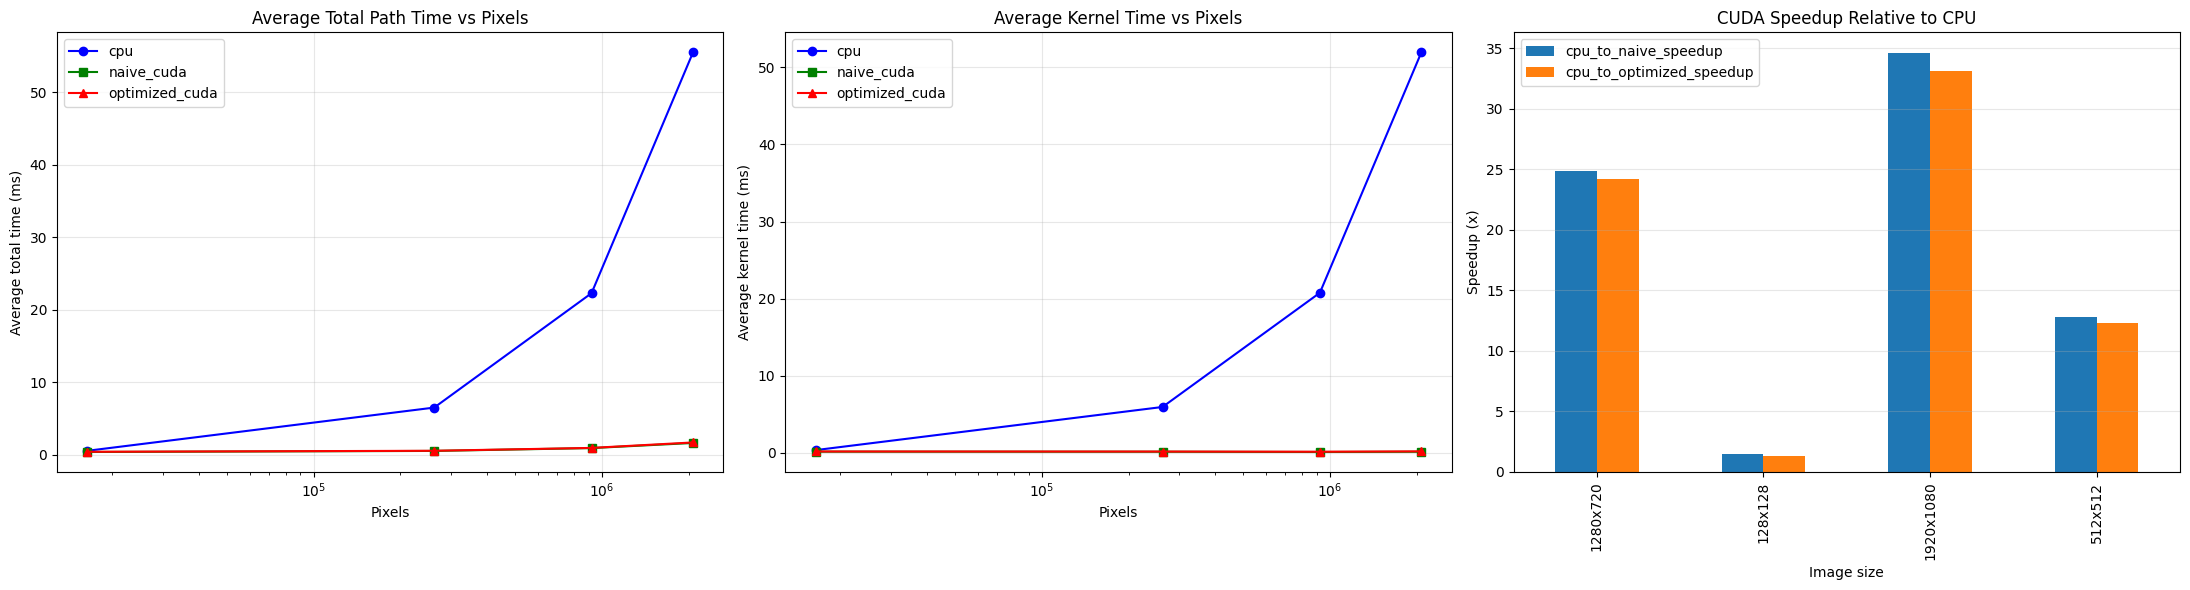

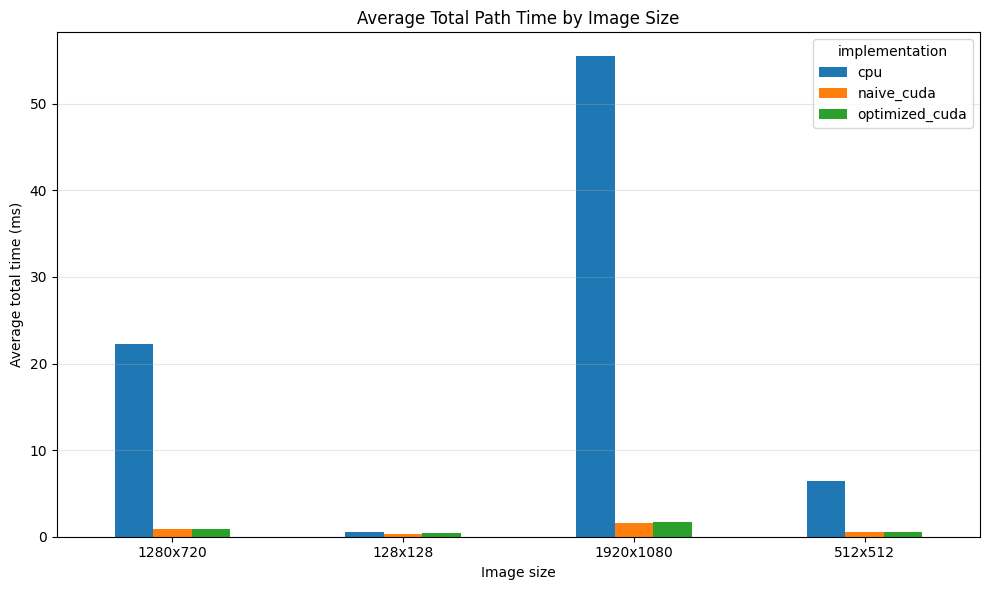

In [16]:
plot_df = results_df.copy()
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

markers = {'cpu': 'o', 'naive_cuda': 's', 'optimized_cuda': '^'}
colors = {'cpu': 'blue', 'naive_cuda': 'green', 'optimized_cuda': 'red'}

for implementation in plot_df['implementation'].unique():
    subset = plot_df[plot_df['implementation'] == implementation]
    axes[0].plot(subset['pixels'], subset['avg_total_ms'], marker=markers[implementation], color=colors[implementation], label=implementation)
    axes[1].plot(subset['pixels'], subset['avg_kernel_ms'], marker=markers[implementation], color=colors[implementation], label=implementation)

pivot_speedup = observation_df.set_index('size')[['cpu_to_naive_speedup', 'cpu_to_optimized_speedup']]
pivot_speedup.plot(kind='bar', ax=axes[2])

axes[0].set_title('Average Total Path Time vs Pixels')
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Average total time (ms)')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title('Average Kernel Time vs Pixels')
axes[1].set_xlabel('Pixels')
axes[1].set_ylabel('Average kernel time (ms)')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].set_title('CUDA Speedup Relative to CPU')
axes[2].set_xlabel('Image size')
axes[2].set_ylabel('Speedup (x)')
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

pivot_total = results_df.pivot(index='size', columns='implementation', values='avg_total_ms')
ax = pivot_total.plot(kind='bar', figsize=(10, 6), rot=0, title='Average Total Path Time by Image Size')
ax.set_xlabel('Image size')
ax.set_ylabel('Average total time (ms)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Detailed Observations from Sobel Benchmark

### 1. Overall Performance Comparison (Total Path Time)
*   **CPU vs. CUDA:** Both naive and optimized CUDA implementations significantly outperform the CPU implementation, especially as image size increases. This is evident from the `cpu_to_naive_speedup` and `cpu_to_optimized_speedup` ratios, which show considerable speed improvements.
*   **Naive CUDA vs. Optimized CUDA:** Interestingly, the **naive CUDA implementation often has a lower total path time than the optimized CUDA version.** This can be seen in the 'Average Total Path Time vs Pixels' plot, where the green line (naive CUDA) is frequently below the red line (optimized CUDA), particularly for larger image sizes.

### 2. Kernel Performance Comparison
*   **Naive CUDA Kernel vs. Optimized CUDA Kernel:** Despite the goal of optimization, the 'Average Kernel Time vs Pixels' plot shows that the naive CUDA kernel (green line) is consistently faster than the optimized CUDA kernel (red line). The `naive_to_optimized_kernel_speedup` values in the `observation_df` are often less than 1, indicating that the naive kernel is faster.

### 3. Analysis of "Optimized" CUDA Behavior
*   The shared memory optimization in `sobel_optimized.cu` was intended to improve performance by reducing global memory accesses. However, the current implementation shows that **the overhead associated with managing shared memory and the cooperative loading mechanism might be offsetting the benefits of reduced global memory access.**
    *   The process of loading the 1-pixel halo into shared memory, especially with the current loop structure, might introduce additional latency or reduce parallelism compared to direct global memory access in the naive version.
    *   Shared memory operations require synchronization (`__syncthreads()`), which can introduce stalls if not managed carefully.

### 4. Scalability with Image Size
*   **CPU Performance:** The CPU implementation's execution time scales much more steeply with increasing pixel count, highlighting its limitation for larger images.
*   **CUDA Performance:** Both CUDA implementations show much better scalability, with their execution times increasing at a significantly slower rate compared to the CPU version. This indicates that GPUs are well-suited for parallel image processing tasks like Sobel filtering.

### Conclusion:
While the idea behind using shared memory in the optimized CUDA kernel was sound for reducing global memory traffic, the current implementation introduces performance overheads that make it slower than the simpler naive CUDA approach for the tested image sizes. Further optimization of the shared memory loading pattern and potentially other kernel parameters would be necessary to truly realize the benefits of the shared memory approach.

### When will Optimized perform better than Naive?
The optimized CUDA implementation, despite underperforming in this specific benchmark, *should* theoretically outperform the naive version under certain conditions, primarily when:

*   **Larger Images:** For significantly larger images (beyond the `1920x1080` tested), the global memory bandwidth bottleneck becomes more pronounced. Shared memory's ability to reuse data from high-speed on-chip memory would become more critical, and the overheads observed here might be amortized over a much larger computation.
*   **More Complex Kernels/Larger Stencils:** If the kernel involved a larger stencil or more complex computations that required repeated access to the same neighborhood data, the benefits of loading data once into shared memory and reusing it would increase. The current 3x3 Sobel kernel has relatively low data reuse.
*   **Reduced Shared Memory Overhead:** With finer-tuned shared memory loading strategies (e.g., ensuring perfectly coalesced loads into shared memory, or reducing the number of `__syncthreads()` if possible) and careful management of thread block dimensions, the overhead could be minimized.
*   **Different Hardware Architectures:** On GPUs with different memory hierarchies or cache behaviors, the trade-offs between global and shared memory access might shift, potentially favoring shared memory more strongly.

In essence, for the optimized shared memory approach to be beneficial, the cost of populating shared memory and the associated synchronization must be significantly outweighed by the reduction in global memory accesses and the speedup from using faster on-chip memory.